In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('CarsData.csv')
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
0,I10,2017,7495,Manual,11630,Petrol,145,60.1,1.0,hyundi
1,Polo,2017,10989,Manual,9200,Petrol,145,58.9,1.0,volkswagen
2,2 Series,2019,27990,Semi-Auto,1614,Diesel,145,49.6,2.0,BMW
3,Yeti Outdoor,2017,12495,Manual,30960,Diesel,150,62.8,2.0,skoda
4,Fiesta,2017,7999,Manual,19353,Petrol,125,54.3,1.2,ford
...,...,...,...,...,...,...,...,...,...,...
97707,Fiesta,2017,10447,Automatic,8337,Petrol,145,54.3,1.0,ford
97708,3 Series,2014,14995,Manual,25372,Diesel,30,61.4,2.0,BMW
97709,Fiesta,2017,8950,Manual,19910,Petrol,125,54.3,1.2,ford
97710,Astra,2017,10700,Automatic,24468,Petrol,125,50.4,1.4,vauxhall


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 97712 entries, 0 to 97711
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         97712 non-null  str    
 1   year          97712 non-null  int64  
 2   price         97712 non-null  int64  
 3   transmission  97712 non-null  str    
 4   mileage       97712 non-null  int64  
 5   fuelType      97712 non-null  str    
 6   tax           97712 non-null  int64  
 7   mpg           97712 non-null  float64
 8   engineSize    97712 non-null  float64
 9   Manufacturer  97712 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 7.5 MB


In [4]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000
mean,2017.066502,16773.487555,23219.475499,120.142408,55.205623,1.664913
std,2.118661,9868.552222,21060.882301,63.357250,16.181659,0.558574
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000
50%,2017.000000,14470.000000,17682.500000,145.000000,54.300000,1.600000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000
max,2024.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Manufacturer    0
dtype: int64

In [7]:
df.nunique()


model             196
year               27
price           13236
transmission        4
mileage         42214
fuelType            5
tax                48
mpg               208
engineSize         40
Manufacturer        9
dtype: int64

In [8]:
df['Manufacturer'].value_counts()


Manufacturer
ford          17811
volkswagen    14893
vauxhall      13258
merc          12860
BMW           10664
Audi          10565
toyota         6699
skoda          6188
hyundi         4774
Name: count, dtype: int64

In [9]:
df['model'].value_counts()


model
 Fiesta     6509
 Golf       4797
 Focus      4555
 C Class    3694
 Corsa      3285
            ... 
 A2            1
 Amica         1
 RS7           1
 Accent        1
220            1
Name: count, Length: 196, dtype: int64

In [10]:
df['fuelType'].value_counts()


fuelType
Petrol      53982
Diesel      40419
Hybrid       3059
Other         246
Electric        6
Name: count, dtype: int64

In [11]:
df['transmission'].value_counts()


transmission
Manual       55502
Semi-Auto    22296
Automatic    19905
Other            9
Name: count, dtype: int64

### EDA (Exploratory Data Analysis)

In [12]:
# Select all numerical and categorical columns
num_cols = df.select_dtypes(include = ['float','int']).columns
cat_cols = df.select_dtypes(include = ['object','category']).columns

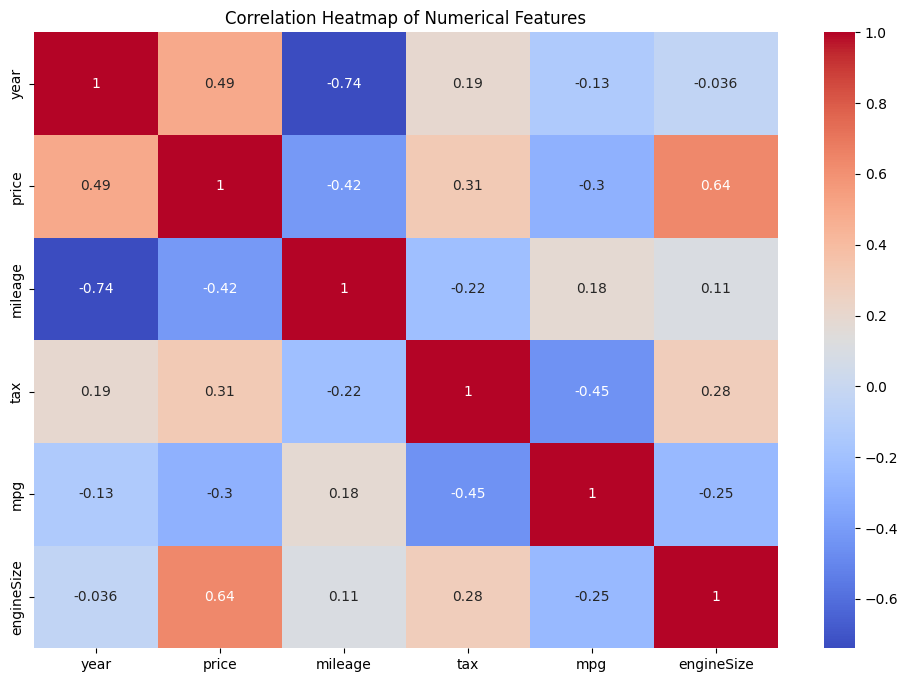

In [13]:
# Correlation heatmap for numerical features
corr = df[num_cols].corr()
plt.figure(figsize = (12,8))
sns.heatmap(corr,cmap = 'coolwarm', annot = True)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

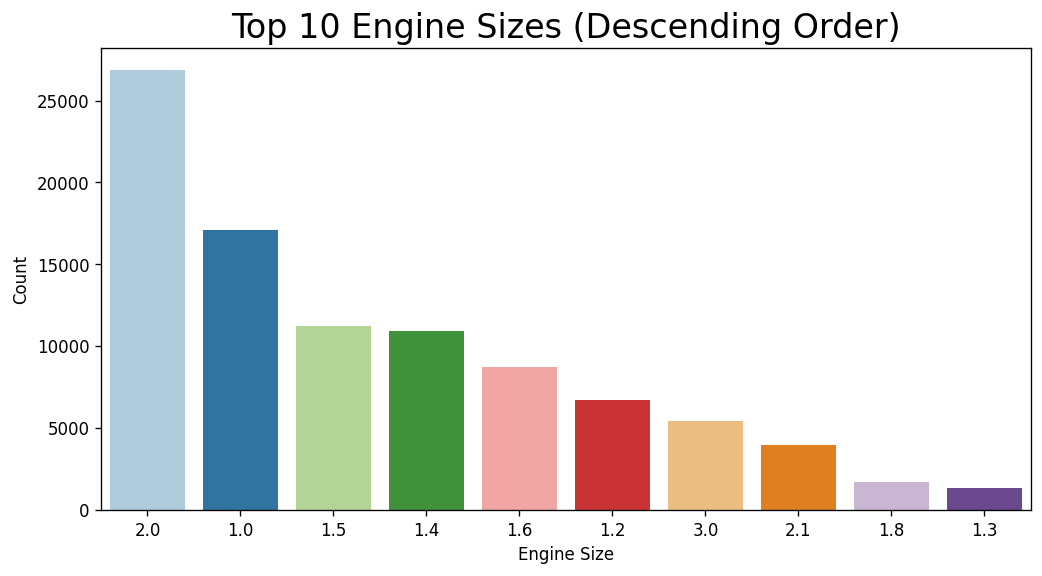

In [14]:
# Count the frequency of each engine size
engine_size_counts = df['engineSize'].value_counts()

# Sort the engine sizes in descending order of frequency
engine_size_counts_sorted = engine_size_counts.sort_values(ascending=False)

# Select the top 10 engine sizes
top_10_engine_sizes = engine_size_counts_sorted.head(10)

# Create the bar plot
plt.figure(figsize=(10, 5), dpi=120)
sns.countplot(data=df[df['engineSize'].isin(top_10_engine_sizes.index)], x='engineSize', order=top_10_engine_sizes.index, palette='Paired')
plt.title("Top 10 Engine Sizes (Descending Order)", fontsize=20)
plt.xlabel("Engine Size")
plt.ylabel("Count")
plt.show()

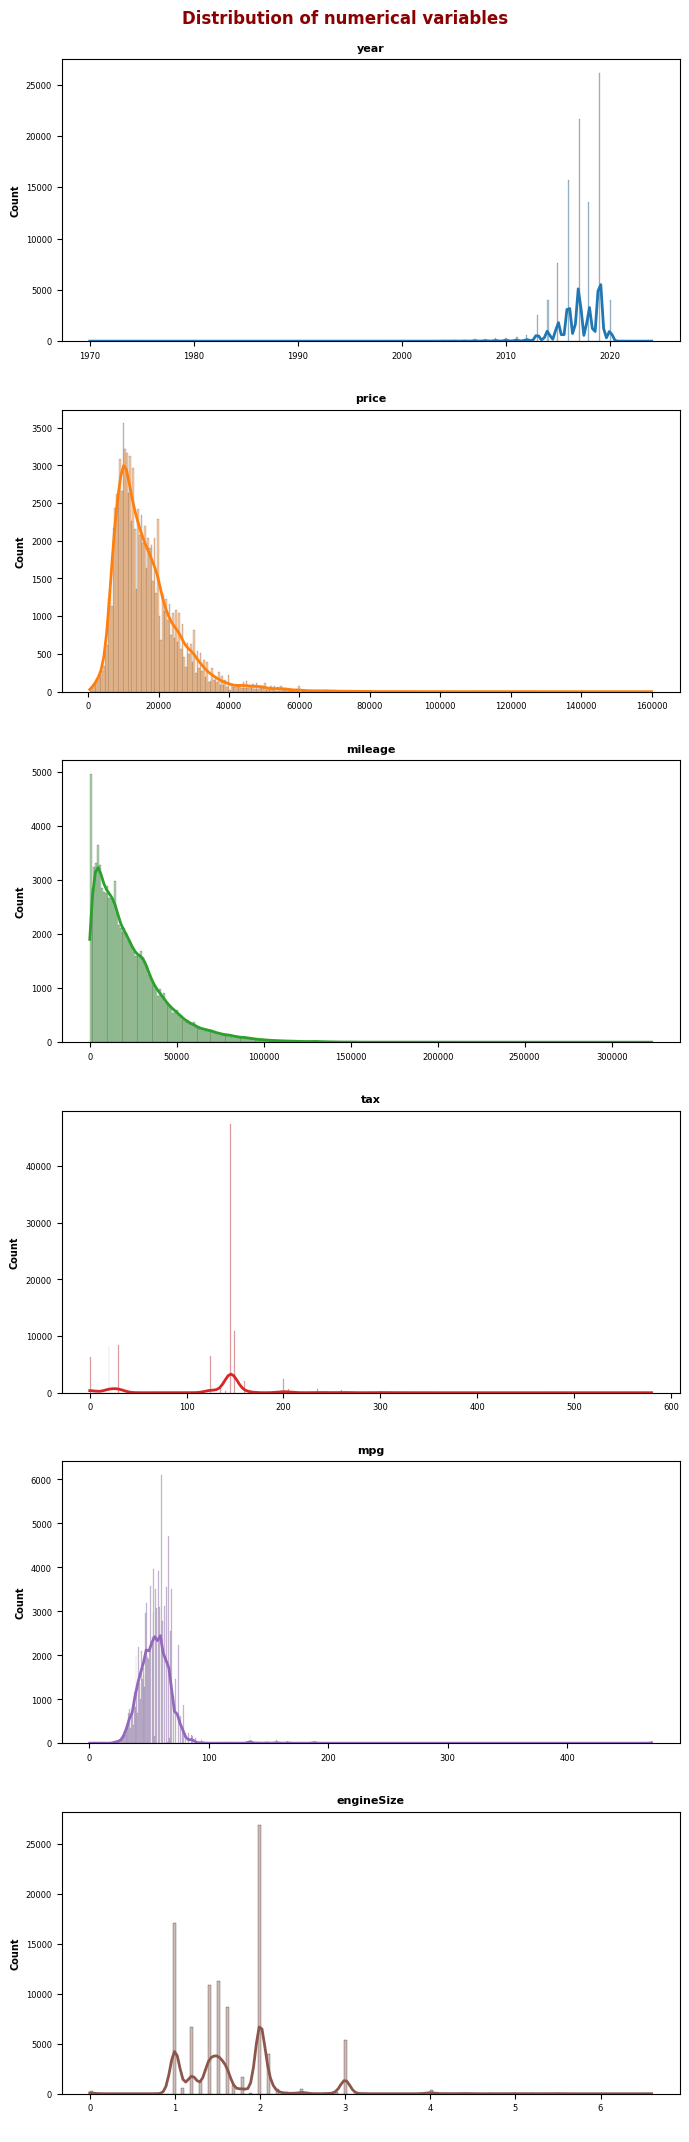

In [15]:
# Distribution of Numerical Variables
fig,axes = plt.subplots(7, 1, figsize = (7, 25))
axes = axes.flat

for i, num_col in enumerate(num_cols):
  sns.histplot(df,
               x = num_col,
               stat = 'count',
               kde = True,
               color = (list(plt.rcParams['axes.prop_cycle'])*2)[i]["color"],
               line_kws = {'linewidth': 2},
               alpha = 0.4,
               ax = axes[i])

  axes[i].set_xlabel(" ")
  axes[i].set_ylabel("Count", fontsize = 7, fontweight = 'bold', color = 'black')
  axes[i].set_title(num_col, fontsize = 8, fontweight = 'bold', color = 'black')
  axes[i].tick_params(labelsize = 6)


fig.delaxes(axes[6])
fig.suptitle('Distribution of numerical variables', fontsize = 12, fontweight = 'bold', color = 'darkred')
fig.tight_layout()
fig.subplots_adjust(top = 0.96)
fig.show()

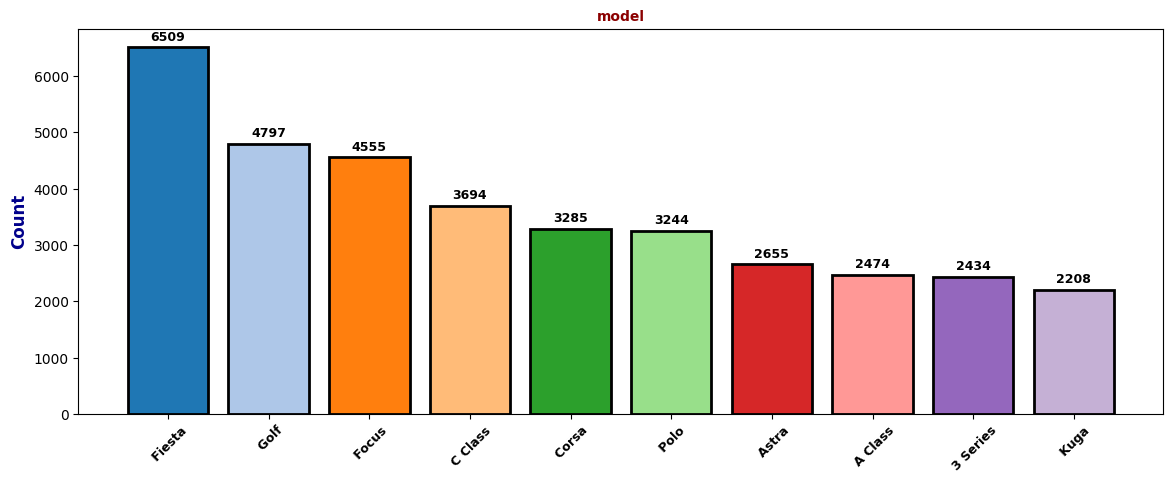

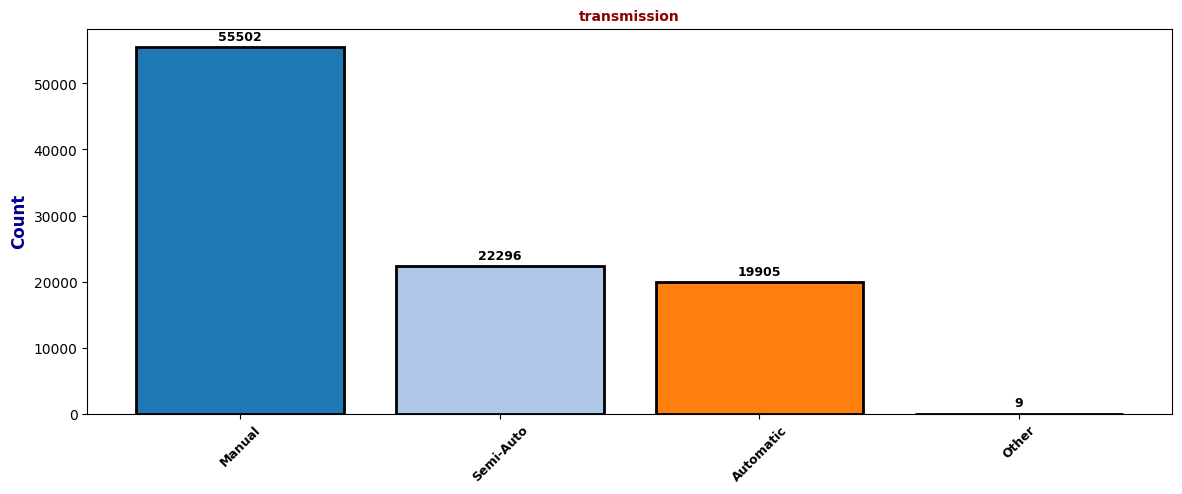

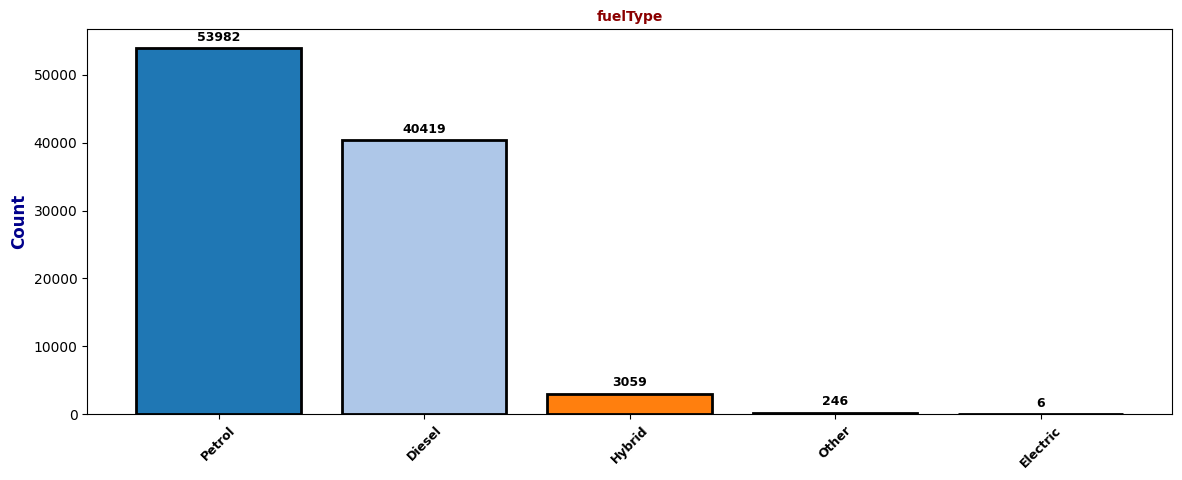

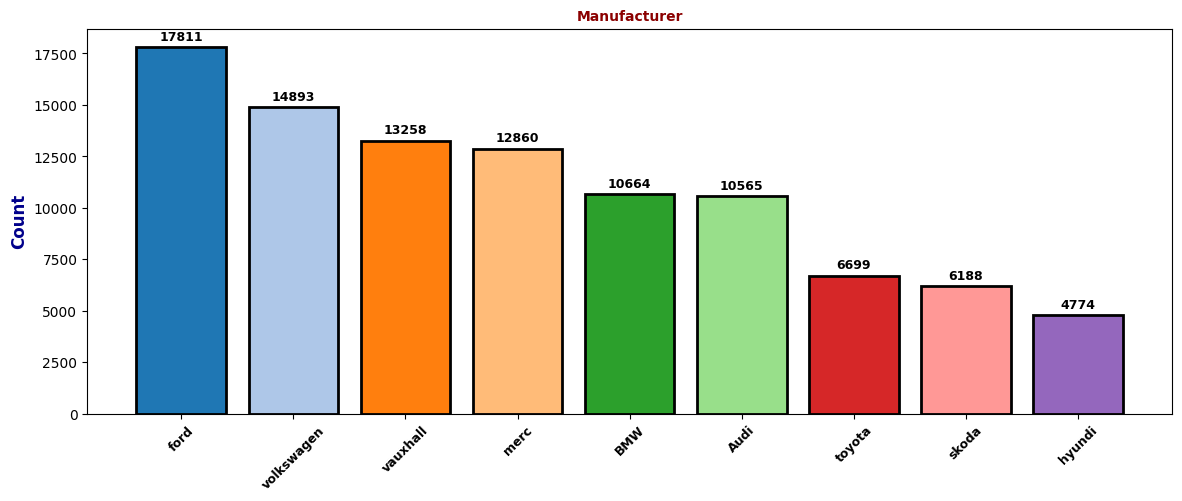

In [16]:
# Distribution of Categorical Variables
cols = [0, 1, 2, 3]

for i in cols:

        if i == 0:

            # We define the size of our figure.
            fig,ax = plt.subplots(figsize=(14,5))

            # 1. We create our dataframe that contains our data to be displayed.
            df_name = df[cat_cols[0]].value_counts().to_frame().head(10)

            # 2.  Extract frequency values for plotting.
            values = df_name.iloc[:,0]
            # 3. We generate the labels for our charts.
            labels = df_name.index.to_list()
            # 4. We generate the color map.
            cmap = plt.get_cmap('tab20')
            colors = cmap(np.arange(len(labels)))


            # 2. Bar chart.
            rects = ax.bar(labels, values, color = colors,
                              edgecolor = 'black', linewidth = 2.0)

            ax.set_title(f"{cat_cols[0]}", fontsize = 10, fontweight = 'bold', color = 'darkred')
            ax.set_ylabel('Count', fontsize = 12, fontweight = 'bold', color = 'darkblue')
            ax.set_xticklabels(labels, fontsize = 9, fontweight = 'bold', rotation = 45)

            # function to label our bars.
            def autolabel(rects):
              for rect in rects:
                height = rect.get_height()
                ax.annotate(text = '{}'.format(height),
                            xy = (rect.get_x() + rect.get_width()/2., height-0.005),
                            xytext = (0,3),
                            textcoords = 'offset points',
                            va = 'bottom',
                            ha = 'center',
                            weight = 'bold',
                            size = 9,
                            color = 'black')

            autolabel(rects) # we label our bars.

            fig.show()
            
        else:
            
            # We define the size of our figure.
            fig,ax = plt.subplots(figsize=(14,5))

            # 1. We create our dataframe that contains our data to be displayed.
            df_name = df[cat_cols[i]].value_counts().to_frame().head(10)

            # 2. We generate the values of our graphs.
            values = df_name.iloc[:,0]
            # 3. We generate the labels for our charts.
            labels = df_name.index.to_list()
            # 4. We generate the color map.
            cmap = plt.get_cmap('tab20')
            colors = cmap(np.arange(len(labels)))


            # 2. Bar chart.
            rects = ax.bar(labels, values, color = colors,
                              edgecolor = 'black', linewidth = 2.0)

            ax.set_title(f"{cat_cols[i]}", fontsize = 10, fontweight = 'bold', color = 'darkred')
            ax.set_ylabel('Count', fontsize = 12, fontweight = 'bold', color = 'darkblue')
            ax.set_xticklabels(labels, fontsize = 9, fontweight = 'bold', rotation = 45)

            # function to label our bars.
            def autolabel(rects):
              for rect in rects:
                height = rect.get_height()
                ax.annotate(text = '{}'.format(height),
                            xy = (rect.get_x() + rect.get_width()/2., height-0.005),
                            xytext = (0,3),
                            textcoords = 'offset points',
                            va = 'bottom',
                            ha = 'center',
                            weight = 'bold',
                            size = 9,
                            color = 'black')

            autolabel(rects) # we label our bars.

            fig.show()

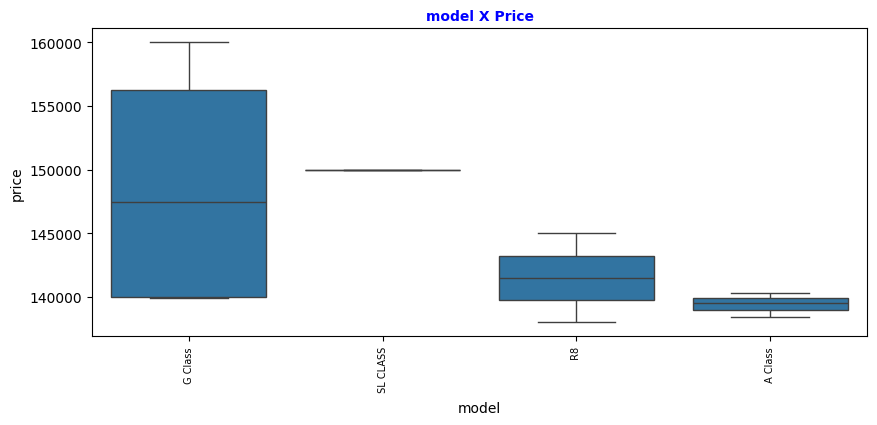

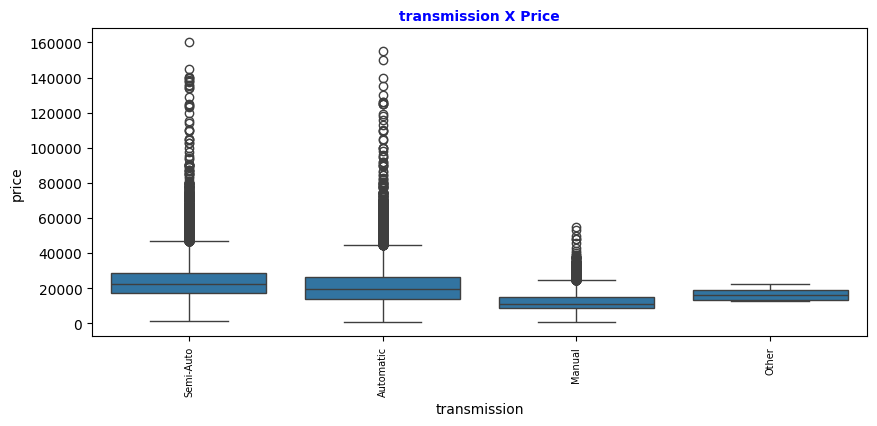

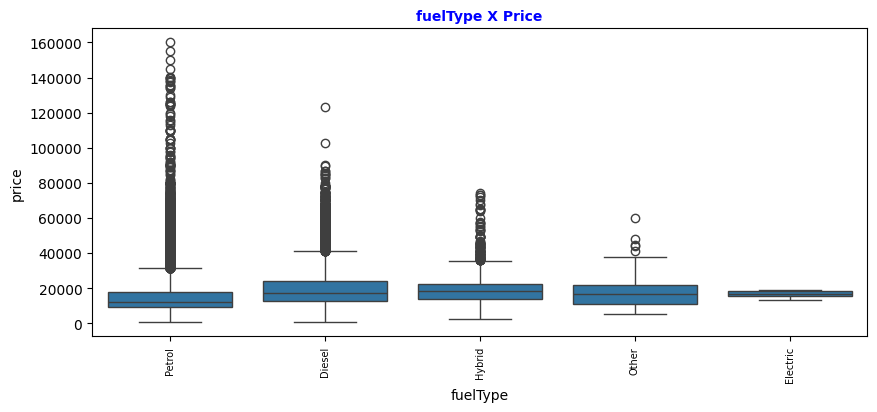

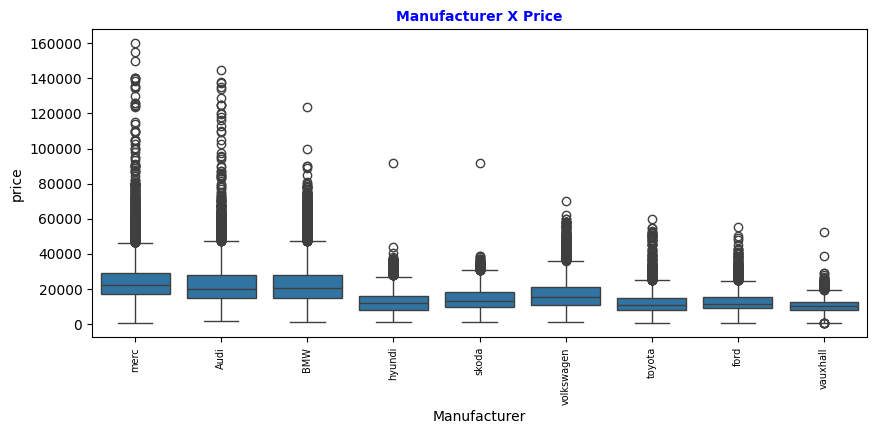

In [17]:
# This code is analyzing how categorical variables affect car price using boxplots.
# Select indices of categorical columns to analyze
cols = [0, 1, 2, 3]

# Sort the dataset by price in descending order
# This helps highlight the most expensive cars
df_top = df.sort_values(["price"], axis=0, ascending=False)

# Loop through selected categorical features
for i in cols:

    # Create a figure for the boxplot
    fig, ax = plt.subplots(figsize=(10,4))

    # Special case for 'model' because there are many unique models
    if i == 0:

        # Plot boxplot of price distribution for top 10 car models
        sns.boxplot(x='model', y='price', data=df_top.head(10))

        # Add title to the plot
        ax.set_title(f"{cat_cols[i]} X Price", fontsize=10, fontweight='bold', color='blue')

        # Rotate x-axis labels for readability
        plt.xticks(rotation=90, fontsize=7)

        plt.show()

    else:

        # Plot price distribution for other categorical variables
        sns.boxplot(x=cat_cols[i], y='price', data=df_top)

        # Add title
        ax.set_title(f"{cat_cols[i]} X Price", fontsize=10, fontweight='bold', color='blue')

        # Rotate labels for readability
        plt.xticks(rotation=90, fontsize=7)

        plt.show()

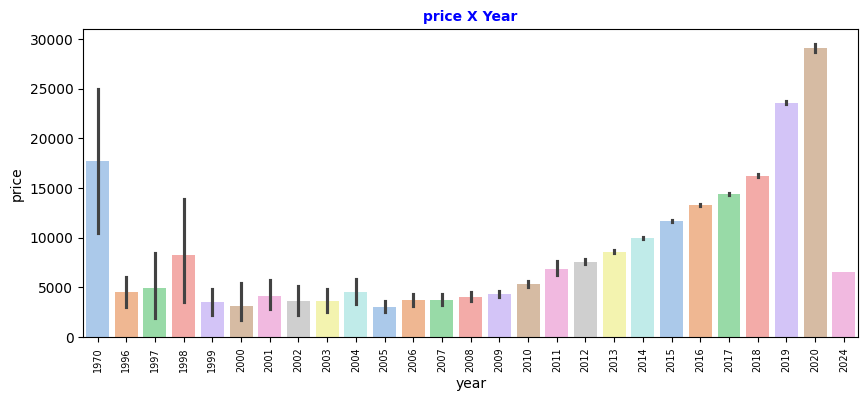

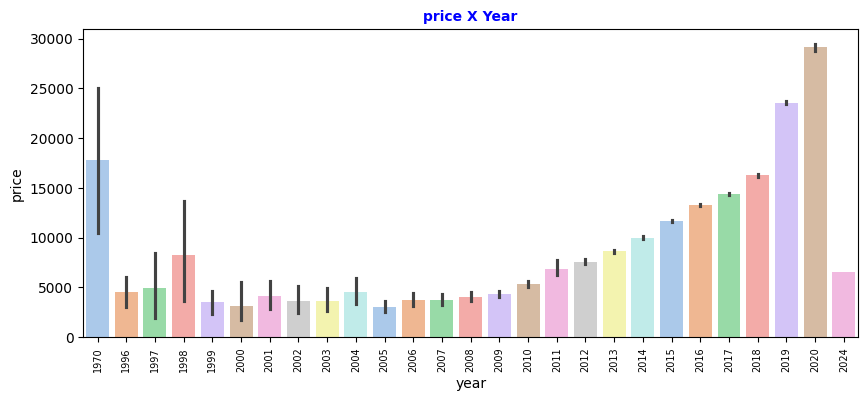

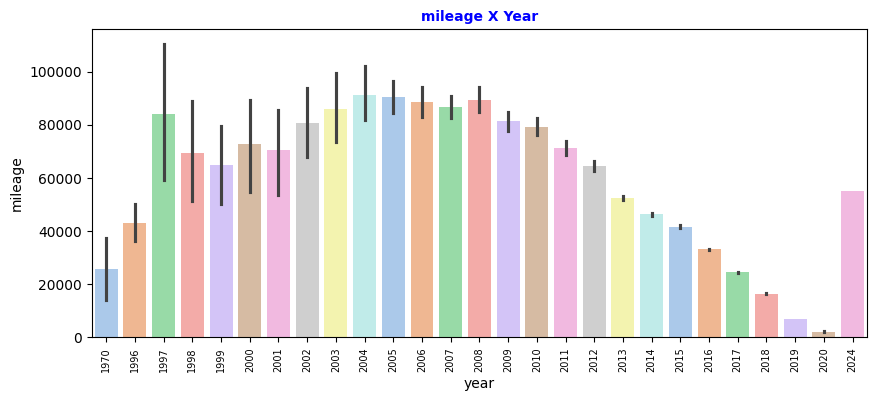

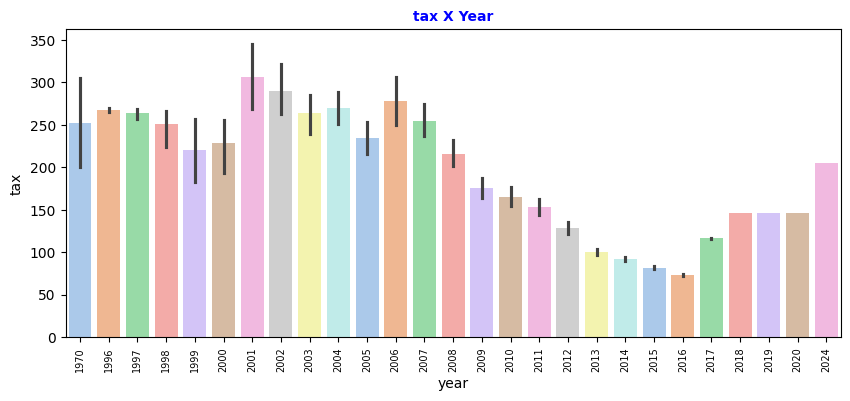

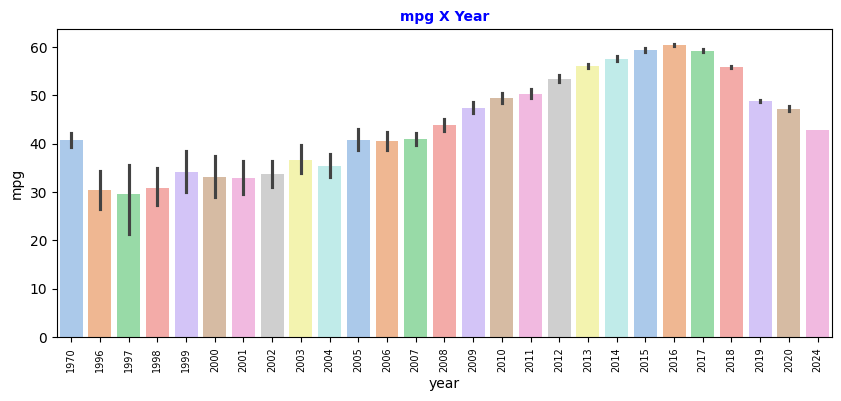

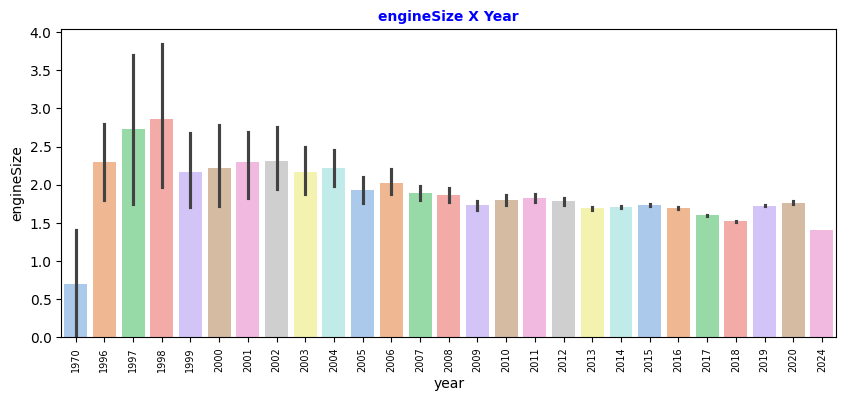

In [18]:
# Analyzing how numerical variables change with respect to the manufacturing year. 
# It creates bar plots comparing year with other numerical features.
for i in num_cols:
        fig, ax = plt.subplots(figsize=(10, 4))

        if i == 'year':
            sns.barplot(data=df, x = 'year', y = 'price', palette="pastel")
            ax.set_title('price'  + " X Year", fontsize = 10, fontweight = 'bold', color = 'blue')
            plt.xticks(rotation=90, fontsize = 7)
            plt.show()
        else:
            sns.barplot(data=df, x = 'year', y = i, palette="pastel")
            ax.set_title(f"{i}"+ " X Year", fontsize = 10, fontweight = 'bold', color = 'blue')
            plt.xticks(rotation=90, fontsize = 7)
            plt.show()

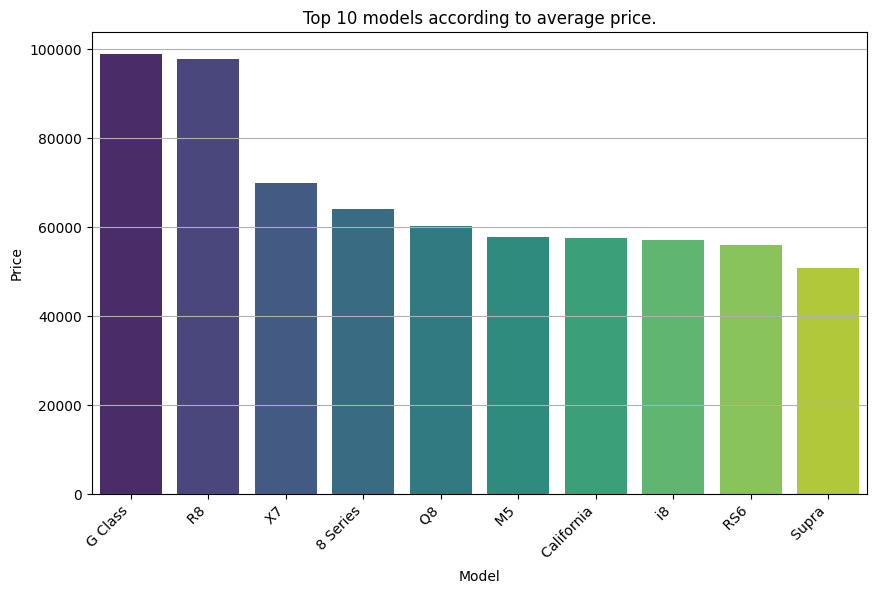

In [19]:
# Analyzing the top 10 most expensive car models based on average price.
char_bar = df.groupby(['model'])[['price']].mean().reset_index()
char_bar = char_bar.sort_values(by=("price"), ascending=False)

top = char_bar.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='model', y='price', data=top, palette='viridis')
plt.title('Top 10 models according to average price.')
plt.xlabel('Model')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

In [20]:
# Analyzing the price distribution of the 'Fiesta' model.
df_fiesta = df[df['model'] == ' Fiesta']
df_fiesta.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
4,Fiesta,2017,7999,Manual,19353,Petrol,125,54.3,1.2,ford
8,Fiesta,2018,9891,Manual,31639,Petrol,145,65.7,1.0,ford
16,Fiesta,2017,10490,Manual,16087,Petrol,0,65.7,1.0,ford
21,Fiesta,2017,12750,Semi-Auto,12687,Petrol,145,54.3,1.0,ford
30,Fiesta,2018,10500,Manual,13427,Petrol,145,65.7,1.0,ford


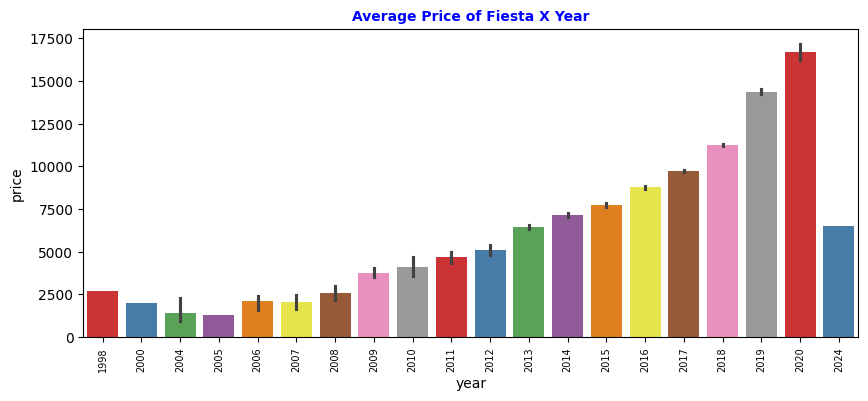

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=df_fiesta, x = 'year', y = 'price', palette="Set1")
ax.set_title('Average Price of Fiesta X Year', fontsize = 10, fontweight = 'bold', color = 'blue')
plt.xticks(rotation=90, fontsize = 7)
plt.show()

Text(0, 0.5, 'Total Price')

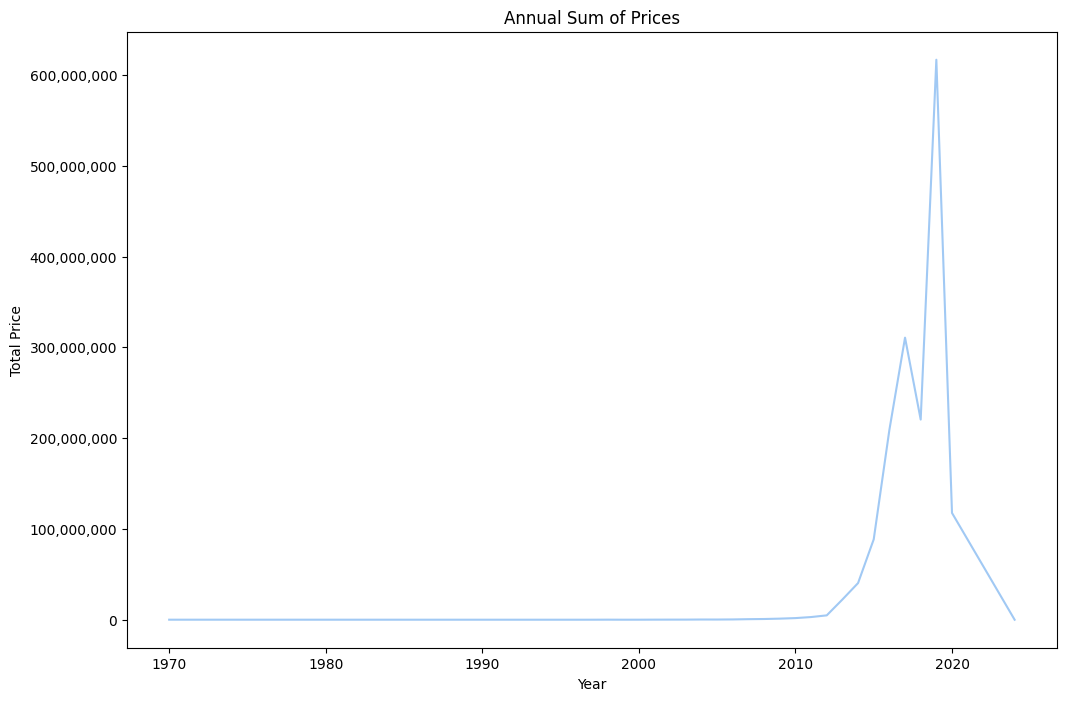

In [22]:
# Analyzing the annual sum of car prices to see how total market value changes over time.

plt.figure(figsize=(12, 8))

# Group the dataset by year and calculate the total price of cars for each year
# Then plot it as a line chart
ax = df.groupby('year')['price'].sum().plot(
    kind='line',
    color=sns.color_palette('pastel')
)

# Format the y-axis numbers with commas (e.g., 1000000 -> 1,000,000)
ax.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))
)

# Add title and axis labels
plt.title('Annual Sum of Prices')
plt.xlabel('Year')
plt.ylabel('Total Price')

In [23]:
# Rotate x-axis labels for better readability
df_temp = df[df.year > 2015]
df_temp

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
0,I10,2017,7495,Manual,11630,Petrol,145,60.1,1.0,hyundi
1,Polo,2017,10989,Manual,9200,Petrol,145,58.9,1.0,volkswagen
2,2 Series,2019,27990,Semi-Auto,1614,Diesel,145,49.6,2.0,BMW
3,Yeti Outdoor,2017,12495,Manual,30960,Diesel,150,62.8,2.0,skoda
4,Fiesta,2017,7999,Manual,19353,Petrol,125,54.3,1.2,ford
...,...,...,...,...,...,...,...,...,...,...
97705,Kuga,2017,14795,Manual,25570,Diesel,150,60.1,2.0,ford
97707,Fiesta,2017,10447,Automatic,8337,Petrol,145,54.3,1.0,ford
97709,Fiesta,2017,8950,Manual,19910,Petrol,125,54.3,1.2,ford
97710,Astra,2017,10700,Automatic,24468,Petrol,125,50.4,1.4,vauxhall


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '2016'),
  Text(1, 0, '2017'),
  Text(2, 0, '2018'),
  Text(3, 0, '2019'),
  Text(4, 0, '2020'),
  Text(5, 0, '2024')])

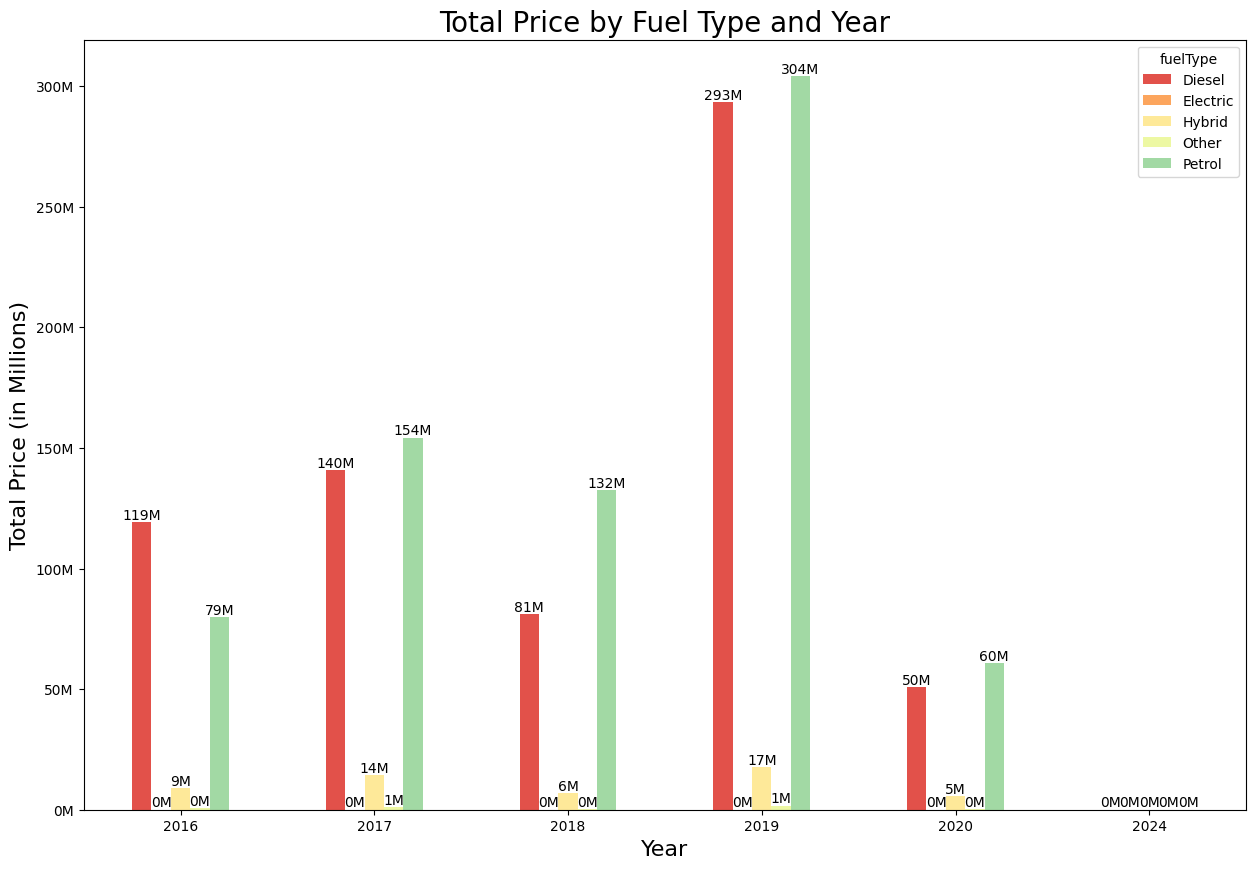

In [24]:
# Analyzing the total price by fuel type and year using a bar plot.
# performing a multi-category analysis of price. 
# It shows how the total price of cars varies by both fuel type and year using a grouped bar chart.
from matplotlib.ticker import FuncFormatter
def millions(x, pos):
    'The two args are the value and tick position'
    return f'{int(x / 1e6)}M'


ax = df_temp.groupby(['year', 'fuelType'])['price'].sum().unstack().plot(
    kind='bar',
    color=sns.color_palette("Spectral"),
    figsize=(15, 10) 
)

formatter = FuncFormatter(millions)

ax.set_title('Total Price by Fuel Type and Year', fontsize=20)
ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Total Price (in Millions)', fontsize=16)

ax.yaxis.set_major_formatter(formatter)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height() / 1e6)}M', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xticks(rotation=0)

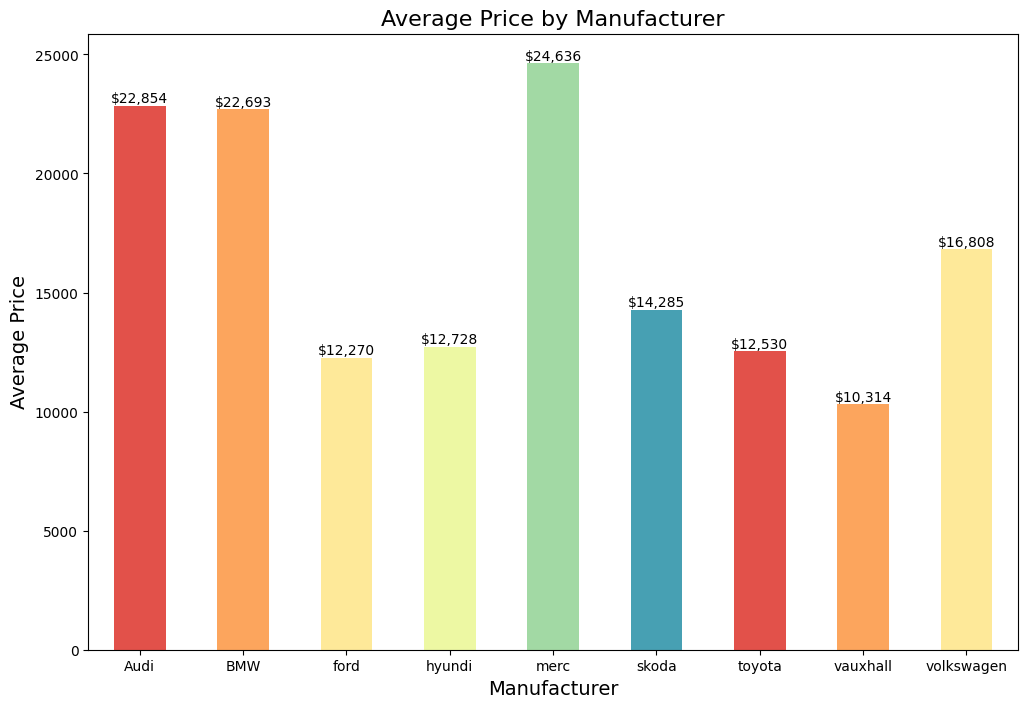

In [25]:
# Analyzing the average price of cars by manufacturer using a bar plot.
plt.figure(figsize=(12, 8))
ax = df.groupby('Manufacturer')['price'].mean().plot(kind='bar', color=sns.color_palette("Spectral"))

ax.set_title('Average Price by Manufacturer', fontsize=16)
ax.set_xlabel('Manufacturer', fontsize=14)
ax.set_ylabel('Average Price', fontsize=14)

plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

In [26]:
# Calculate the total price of cars for each model and sort them from lowest to highest
df.groupby("model")['price'].sum().sort_values()

model
Accent          1295
Amica           1750
A2              2490
Escort          3000
Streetka        3849
              ...   
E Class     48988844
Focus       60030224
Fiesta      66332283
Golf        79811121
C Class     87391114
Name: price, Length: 196, dtype: int64

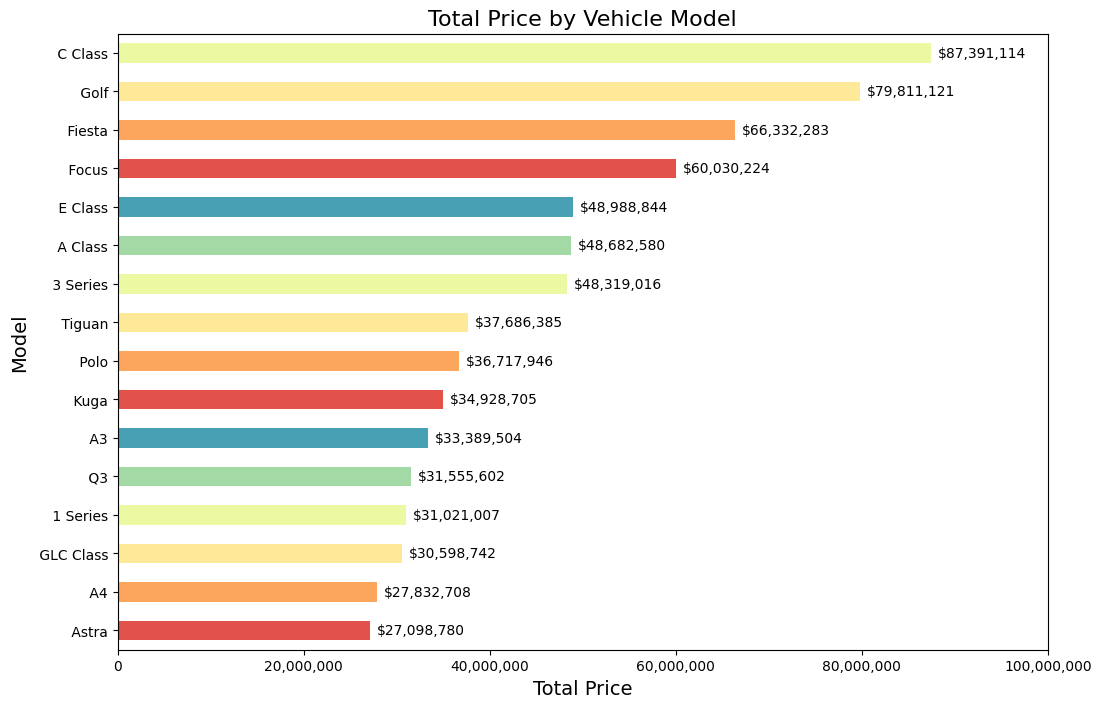

In [27]:
# This code creates a horizontal bar chart showing the total price contribution of different car models. 
# It highlights models whose combined prices sum up to the highest values.
plt.figure(figsize=(12, 8))
ax = df.groupby("model")['price'].sum().sort_values(ascending=False)[15::-1].plot(
    kind='barh',
    color=sns.color_palette("Spectral")
)

ax.set_title('Total Price by Vehicle Model', fontsize=16)
ax.set_xlabel('Total Price', fontsize=14)
ax.set_ylabel('Model', fontsize=14)

ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
for p in ax.patches:
    ax.annotate(f'${p.get_width():,.0f}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, color='black', xytext=(5, 0),
                textcoords='offset points')

ax.set_xlim(0, 100_000_000)
plt.show()

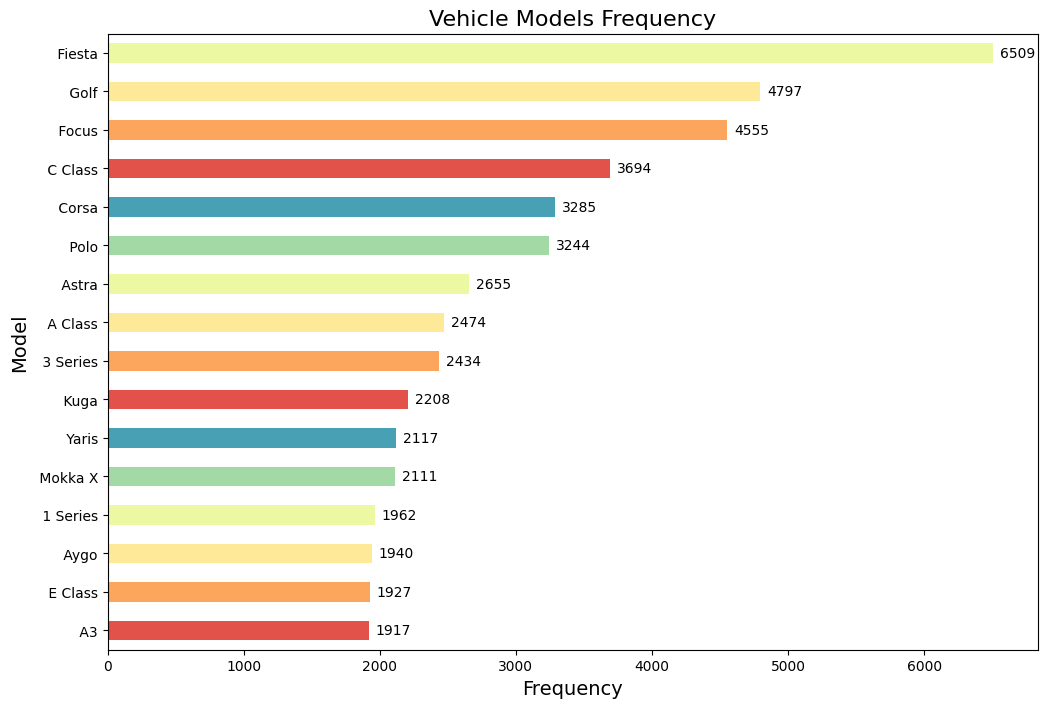

In [28]:
# A frequency analysis of vehicle models was performed to understand the distribution of models in the dataset. 
# The results show that certain models appear significantly more often than others.
plt.figure(figsize=(12, 8))
ax = df.model.value_counts()[15::-1].plot(kind='barh', x='model', y='count', color=sns.color_palette("Spectral"))

ax.set_title('Vehicle Models Frequency', fontsize=16)
ax.set_xlabel('Frequency', fontsize=14)
ax.set_ylabel('Model', fontsize=14)

for p in ax.patches:
    ax.annotate(f'{p.get_width()}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, color='black', xytext=(5, 0),
                textcoords='offset points')

### Feature Engineering


In [29]:
# Remove the 'model' column from the dataset since it may contain too many unique categories
# and may not be useful or practical for the machine learning model
df.drop(columns=['model'], inplace=True)

In [30]:
# Categorical Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['transmission'] = le.fit_transform(df['transmission'])
df['fuelType'] = le.fit_transform(df['fuelType'])
df['Manufacturer'] = le.fit_transform(df['Manufacturer'])

In [31]:
df

,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
0,2017,7495,1,11630,4,145,60.1,1.0,3
1,2017,10989,1,9200,4,145,58.9,1.0,8
2,2019,27990,3,1614,0,145,49.6,2.0,1
3,2017,12495,1,30960,0,150,62.8,2.0,5
4,2017,7999,1,19353,4,125,54.3,1.2,2
...,...,...,...,...,...,...,...,...,...
97707,2017,10447,0,8337,4,145,54.3,1.0,2
97708,2014,14995,1,25372,0,30,61.4,2.0,1
97709,2017,8950,1,19910,4,125,54.3,1.2,2
97710,2017,10700,0,24468,4,125,50.4,1.4,7


### Model


In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error

In [33]:
# Separating features and target variable for machine learning
x= df.drop('price',axis=1)
y= df['price']

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [35]:
# Linear Regression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
linear_r2 = r2_score(y_test, y_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
linear_mae = mean_absolute_error(y_test, y_pred)

print('Linear Regression R2 Score:', r2_score(y_test, y_pred))
print('Linear Regression RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('Linear Regression MAE:', linear_mae)

Linear Regression R2 Score: 0.7151628410670627
Linear Regression RMSE Score: 5265.773252968263
Linear Regression MAE: 3487.282022242062


In [36]:
# Decision Tree Regressor
model = DecisionTreeRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
dt_r2 = r2_score(y_test, y_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
dt_mae = mean_absolute_error(y_test, y_pred)

print('DecisionTreeRegressor R2 Score:', r2_score(y_test, y_pred))
print('DecisionTreeRegressor RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('Decision Tree MAE:', dt_mae)

DecisionTreeRegressor R2 Score: 0.8931086099433153
DecisionTreeRegressor RMSE Score: 3225.7833353501715
Decision Tree MAE: 1730.7687985955267


In [37]:
# Random Forest Regressor
model = RandomForestRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
rf_r2 = r2_score(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_mae = mean_absolute_error(y_test, y_pred)

print('RandomForestRegressor R2 Score:', r2_score(y_test, y_pred))
print('RandomForestRegressor RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('RandomForestRegressor MAE:', rf_mae)

RandomForestRegressor R2 Score: 0.9322427120067556
RandomForestRegressor RMSE Score: 2568.2768611065335
RandomForestRegressor MAE: 1374.3448225103173


In [38]:
# Gradient Boosting Regressor
model = GradientBoostingRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
gb_r2 = r2_score(y_test, y_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
gb_mae = mean_absolute_error(y_test, y_pred)

print('GradientBoostingRegressor R2 Score:', r2_score(y_test, y_pred))
print('GradientBoostingRegressor RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('GradientBoostingRegressor MAE:', gb_mae)

GradientBoostingRegressor R2 Score: 0.8848697884230261
GradientBoostingRegressor RMSE Score: 3347.792121214194
GradientBoostingRegressor MAE: 2148.3163172381296


In [ ]:

# KNN REGRESSOR MODEL

# Import KNN Regressor model
from sklearn.neighbors import KNeighborsRegressor

# Create the KNN model
knn_model = KNeighborsRegressor()


knn_model.fit(x_train, y_train)
y_pred = knn_model.predict(x_test)

knn_r2 = r2_score(y_test, y_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
knn_mae = mean_absolute_error(y_test, y_pred)

# Print the results
print("KNN Regressor R2 Score:", knn_r2)
print("KNN Regressor RMSE:", knn_rmse)
print("KNN Regressor MAE:", knn_mae)

KNN Regressor R2 Score: 0.4936065058361253
KNN Regressor RMSE: 7021.144162151899
KNN Regressor MAE: 4899.367190298317


In [60]:

# =====================================
# XGBOOST REGRESSOR
# =====================================

from xgboost import XGBRegressor

xgb_model = XGBRegressor()

xgb_model.fit(x_train, y_train)

y_pred = xgb_model.predict(x_test)

# Evaluation
xgb_r2 = r2_score(y_test, y_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_mae = mean_absolute_error(y_test, y_pred)

print("XGBoost R2:", xgb_r2)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAE:", xgb_mae)

XGBoost R2: 0.9334324598312378
XGBoost RMSE: 2545.6283114390444
XGBoost MAE: 1482.92236328125


In [61]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(78169, 8)
(19543, 8)
(78169,)
(19543,)


In [90]:
## =====================================
# MODEL COMPARISON TABLE (UPDATED)
# =====================================

model_results = {
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "XGBoost"
    ],
    
    "R2 Score": [
        linear_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        knn_r2,
        xgb_r2
    ],
    
    "RMSE": [
        linear_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse,
        knn_rmse,
        xgb_rmse
    ],
    
    "MAE": [
        linear_mae,
        dt_mae,
        rf_mae,
        gb_mae,
        knn_mae,
        xgb_mae
    ]
}

results_df = pd.DataFrame(model_results)

print(results_df)

               Model  R2 Score         RMSE          MAE
0  Linear Regression  0.715163  5265.773253  3487.282022
1      Decision Tree  0.893109  3225.783335  1730.768799
2      Random Forest  0.932243  2568.276861  1374.344823
3  Gradient Boosting  0.884870  3347.792121  2148.316317
4                KNN  0.493607  7021.144162  4899.367190
5            XGBoost  0.933432  2545.628311  1482.922363


In [91]:
# =====================================
# FIND BEST MODEL USING MULTIPLE METRICS
# =====================================

# Sort models:
# - Highest R2 (descending)
# - Lowest RMSE (ascending)
# - Lowest MAE (ascending)

sorted_df = results_df.sort_values(
    by=["R2 Score", "RMSE", "MAE"],
    ascending=[False, True, True]
)

# Select best model
best_model = sorted_df.iloc[0]

# Display result
print("Best Model Based on R2, RMSE and MAE:")
print(best_model)

print("\nBest Model Summary:")
print(f"Model: {best_model['Model']}")
print(f"R2 Score: {best_model['R2 Score']}")
print(f"RMSE: {best_model['RMSE']}")
print(f"MAE: {best_model['MAE']}")

Best Model Based on R2, RMSE and MAE:
Model           XGBoost
R2 Score       0.933432
RMSE        2545.628311
MAE         1482.922363
Name: 5, dtype: object

Best Model Summary:
Model: XGBoost
R2 Score: 0.9334324598312378
RMSE: 2545.6283114390444
MAE: 1482.92236328125


In [92]:
# =====================================
# XGBOOST MODEL (FOR FEATURE IMPORTANCE)
# =====================================

from xgboost import XGBRegressor

xgb_model = XGBRegressor()

xgb_model.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [93]:
# =====================================
# FEATURE IMPORTANCE ANALYSIS (XGBOOST)
# =====================================

# Get feature importance from XGBoost model
importances = xgb_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importances
})

# Sort features by importance (highest first)
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display top features
print("Top Features Influencing Car Price:\n")
print(feature_importance_df)

Top Features Influencing Car Price:

        Feature  Importance
0    engineSize    0.464026
1          year    0.206498
2       mileage    0.117278
3  transmission    0.064863
4  Manufacturer    0.047032
5      fuelType    0.040233
6           mpg    0.036178
7           tax    0.023892


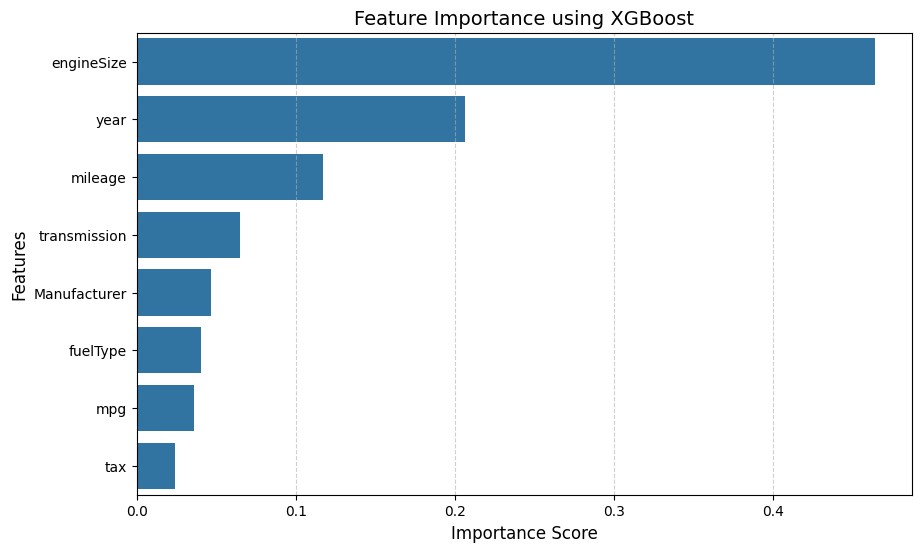

In [94]:
# =====================================
# FEATURE IMPORTANCE PLOT
# =====================================

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df,
)

plt.title("Feature Importance using XGBoost", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

Feature importance was analyzed using the XGBoost model, which identified the most influential variables affecting car price prediction. The results indicate that features such as year, mileage, and engine size contribute significantly to the prediction.

In [95]:

# IMPORT CROSS VALIDATION

from sklearn.model_selection import cross_val_score

Cross-validation was performed using multiple evaluation metrics including R², RMSE, and MAE. This provided a comprehensive assessment of model performance and robustness.

In [96]:
# =====================================
# CROSS VALIDATION WITH MULTIPLE METRICS
# =====================================

from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    xgb_model,
    x,
    y,
    cv=5,
    scoring={
        'r2': 'r2',
        'rmse': 'neg_mean_squared_error',
        'mae': 'neg_mean_absolute_error'
    },
    n_jobs=-1
)

# Convert negative values to positive
rmse_scores = np.sqrt(-cv_results['test_rmse'])
mae_scores = -cv_results['test_mae']
r2_scores = cv_results['test_r2']

# Print results
print("R2 Scores:", r2_scores)
print("RMSE Scores:", rmse_scores)
print("MAE Scores:", mae_scores)

print("\nAverage R2:", r2_scores.mean())
print("Average RMSE:", rmse_scores.mean())
print("Average MAE:", mae_scores.mean())

R2 Scores: [0.94483685 0.93142164 0.94252419 0.93981236 0.94507676]
RMSE Scores: [2369.23194306 2602.89790426 2363.97821479 2385.91439494 2278.52507118]
MAE Scores: [1510.6932373  1501.00024414 1460.14550781 1479.01074219 1449.67944336]

Average R2: 0.9407343626022339
Average RMSE: 2400.1095056461572
Average MAE: 1480.1058349609375


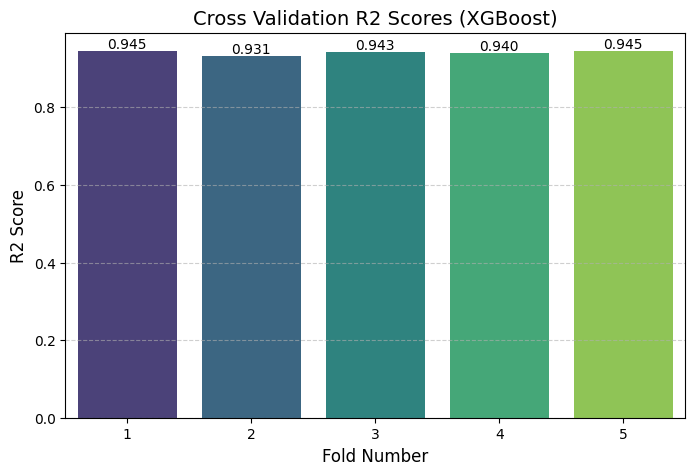

In [97]:
# =====================================
# CROSS VALIDATION VISUALIZATION (R2)
# =====================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=list(range(1, 6)),
    y=r2_scores,
    palette="viridis"
)

# Add value labels on bars
for i, v in enumerate(r2_scores):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom', fontsize=10)

plt.title("Cross Validation R2 Scores (XGBoost)", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("R2 Score", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

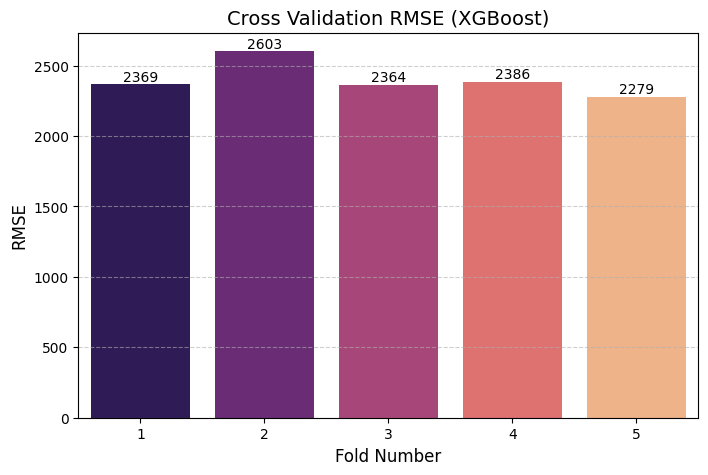

In [98]:
# =====================================
# CROSS VALIDATION VISUALIZATION (RMSE)
# =====================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=list(range(1, 6)),
    y=rmse_scores,
    palette="magma"
)

for i, v in enumerate(rmse_scores):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom', fontsize=10)

plt.title("Cross Validation RMSE (XGBoost)", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("RMSE", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

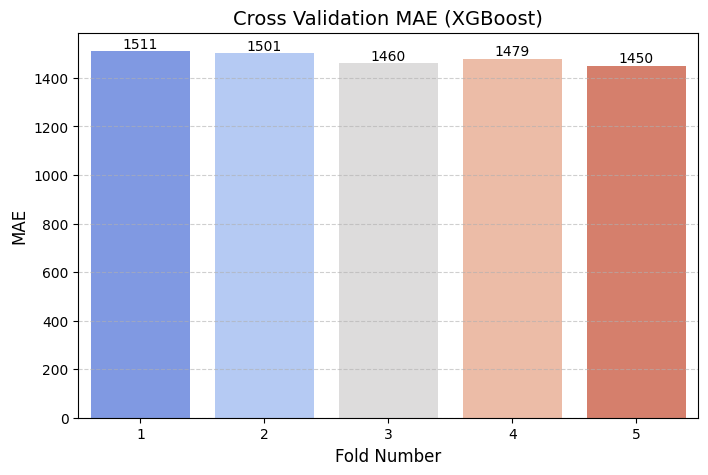

In [99]:
# =====================================
# CROSS VALIDATION VISUALIZATION (MAE)
# =====================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=list(range(1, 6)),
    y=mae_scores,
    palette="coolwarm"
)

for i, v in enumerate(mae_scores):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom', fontsize=10)

plt.title("Cross Validation MAE (XGBoost)", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("MAE", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [100]:
# =====================================
# IMPORT GRID SEARCH FOR TUNING
# =====================================

from sklearn.model_selection import GridSearchCV

In [102]:


param_grid = {
    'n_estimators': [100],
    'max_depth': [3, 6],
    'learning_rate': [0.1]
}

In [103]:
# =====================================
# GRID SEARCH FOR BEST PARAMETERS (XGBOOST)
# =====================================

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Create XGBoost model
xgb = XGBRegressor(
    objective='reg:squarederror',  # important for regression
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,                 # reduced from 5 → faster
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Train Grid Search
grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1], 'max_depth': [3, 6], 'n_estimators': [100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

Grid search identified the optimal hyperparameters for the XGBoost model, resulting in improved predictive performance. The best configuration achieved the highest cross-validation R² score.

In [104]:
# =====================================
# BEST PARAMETERS + MODEL SUMMARY
# =====================================

print("Best Parameters Found:\n")
print(grid_search.best_params_)

print("\nBest Cross-Validation R2 Score:")
print(grid_search.best_score_)

Best Parameters Found:

{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}

Best Cross-Validation R2 Score:
0.9319192171096802


In [105]:
# =====================================
# TRAIN BEST XGBOOST MODEL
# =====================================

# Get best model from GridSearch
best_xgb = grid_search.best_estimator_

# Make predictions
y_pred = best_xgb.predict(x_test)

# Evaluation metrics
tuned_r2 = r2_score(y_test, y_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
tuned_mae = mean_absolute_error(y_test, y_pred)

# Display results
print("\n===== TUNED XGBOOST PERFORMANCE =====")

print(f"R2 Score  : {tuned_r2:.4f}")
print(f"RMSE      : {tuned_rmse:.2f}")
print(f"MAE       : {tuned_mae:.2f}")


===== TUNED XGBOOST PERFORMANCE =====
R2 Score  : 0.9253
RMSE      : 2696.56
MAE       : 1633.16


In [106]:
# =====================================
# PREDICT USING BEST MODEL (XGBOOST)
# =====================================

# Predict prices using the tuned XGBoost model
y_pred_best = best_xgb.predict(x_test)

print("Prediction completed using tuned XGBoost model.")

Prediction completed using tuned XGBoost model.


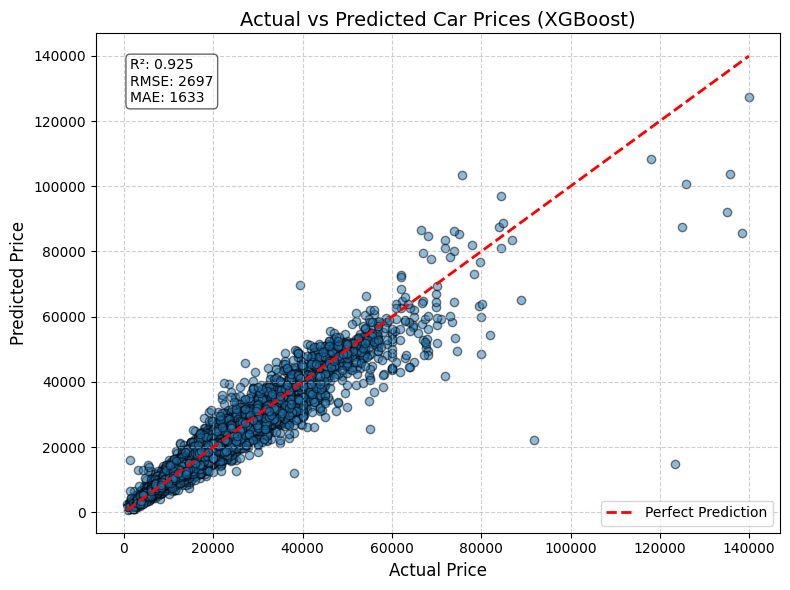

In [107]:
# =====================================
# IMPROVED ACTUAL VS PREDICTED PLOT (FINAL)
# =====================================

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.5,
    edgecolors='k'
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

# Labels and title
plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.title("Actual vs Predicted Car Prices (XGBoost)", fontsize=14)

# Add metrics text on plot
plt.text(
    0.05, 0.95,
    f"R²: {tuned_r2:.3f}\nRMSE: {tuned_rmse:.0f}\nMAE: {tuned_mae:.0f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.6)
)

# Legend
plt.legend()

# Grid
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

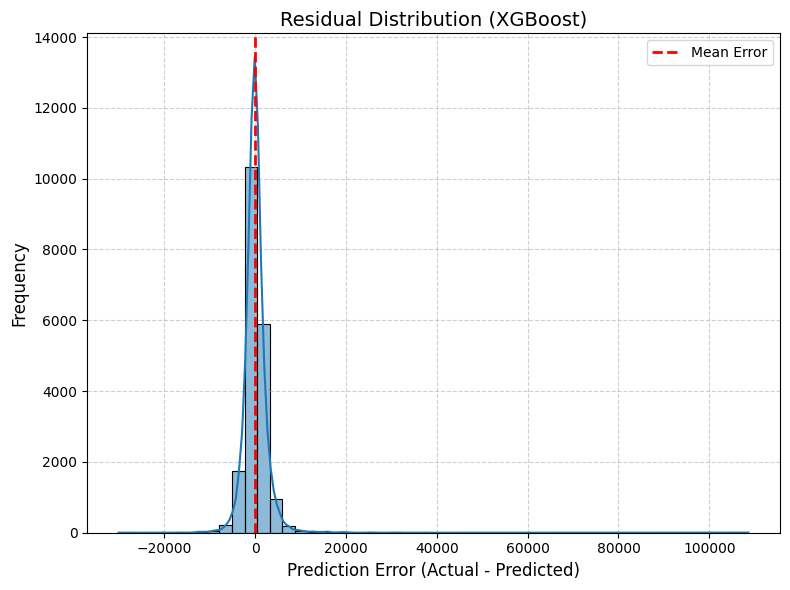

In [108]:
# =====================================
# RESIDUAL ANALYSIS (IMPROVED)
# =====================================

# Calculate residuals
residuals = y_test - y_pred_best

plt.figure(figsize=(8,6))

# Histogram with KDE
sns.histplot(residuals, kde=True, bins=50)

# Mean line (important)
plt.axvline(residuals.mean(), color='red', linestyle='--', linewidth=2, label='Mean Error')

# Labels and title
plt.title("Residual Distribution (XGBoost)", fontsize=14)
plt.xlabel("Prediction Error (Actual - Predicted)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Legend
plt.legend()

# Grid
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

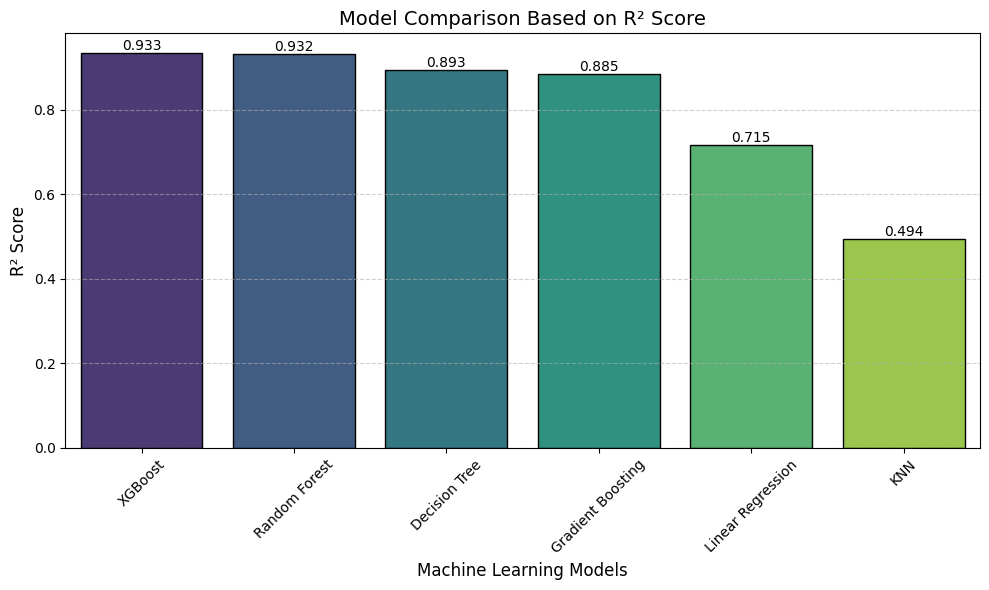

In [109]:
# =====================================
# MODEL PERFORMANCE VISUALIZATION (IMPROVED)
# =====================================

# Sort models by R2 score (best first)
results_df_sorted = results_df.sort_values(by="R2 Score", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results_df_sorted,
    palette="viridis",
    edgecolor='black'
)

# Add value labels on bars
for i, v in enumerate(results_df_sorted["R2 Score"]):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom', fontsize=10)

# Title and labels
plt.title("Model Comparison Based on R² Score", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("R² Score", fontsize=12)

# Rotate labels for readability
plt.xticks(rotation=45)

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

In [110]:
# =====================================
# STORE MODEL PERFORMANCE METRICS
# =====================================

algorithm = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "KNN",
    "XGBRegressor"
]

R2 = [
    linear_r2,
    dt_r2,
    rf_r2,
    gb_r2,
    knn_r2,
    xgb_r2
]

RMSE = [
    linear_rmse,
    dt_rmse,
    rf_rmse,
    gb_rmse,
    knn_rmse,
    xgb_rmse
]

MAE = [
    linear_mae,
    dt_mae,
    rf_mae,
    gb_mae,
    knn_mae,
    xgb_mae
]

In [111]:
print(len(algorithm))
print(len(R2))
print(len(RMSE))
print(len(MAE))

6
6
6
6


In [113]:
# =====================================
# CREATE RESULTS DATAFRAME 
# =====================================

# Ensure all lists are equal length
assert len(algorithm) == len(R2) == len(RMSE) == len(MAE), "List lengths are not equal!"

# Create DataFrame
results_df = pd.DataFrame({
    "Model": algorithm,
    "R2 Score": R2,
    "RMSE": RMSE,
    "MAE": MAE
})

# Sort by best performance
results_df = results_df.sort_values(
    by=["R2 Score", "RMSE", "MAE"],
    ascending=[False, True, True]
).reset_index(drop=True)

# Display results
print("\n===== MODEL PERFORMANCE COMPARISON =====\n")
print(results_df)


===== MODEL PERFORMANCE COMPARISON =====

               Model  R2 Score         RMSE          MAE
0       XGBRegressor  0.933432  2545.628311  1482.922363
1      Random Forest  0.932243  2568.276861  1374.344823
2      Decision Tree  0.893109  3225.783335  1730.768799
3  Gradient Boosting  0.884870  3347.792121  2148.316317
4  Linear Regression  0.715163  5265.773253  3487.282022
5                KNN  0.493607  7021.144162  4899.367190


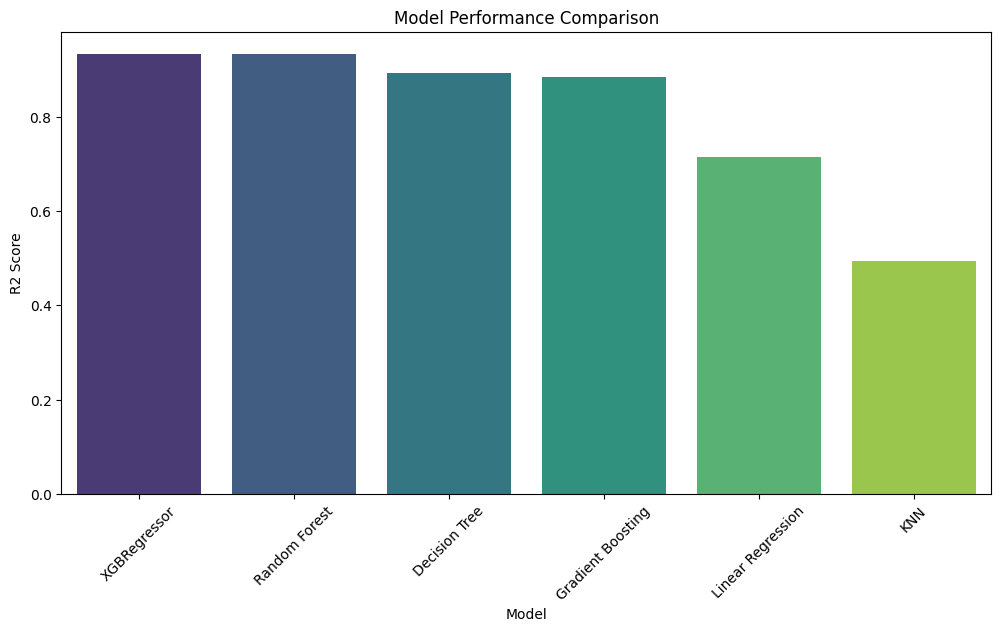

In [117]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',          
    y='R2 Score',
    data=results_df,
    palette='viridis'
)

plt.title("Model Performance Comparison")
plt.xticks(rotation=45)

plt.show()

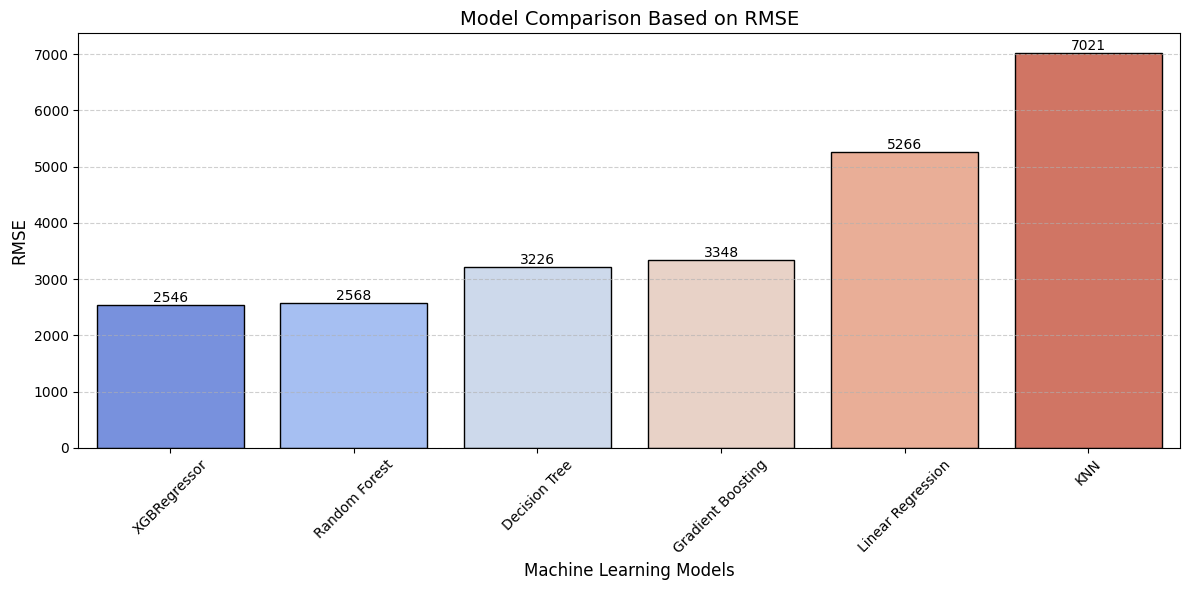

In [119]:
# =====================================
# MODEL COMPARISON USING RMSE (IMPROVED)
# =====================================

# Sort by RMSE (lower is better)
results_sorted = results_df.sort_values(by="RMSE", ascending=True)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='RMSE',
    data=results_sorted,
    palette='coolwarm',
    edgecolor='black'
)

# Add value labels
for i, v in enumerate(results_sorted['RMSE']):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom', fontsize=10)

# Titles and labels
plt.title("Model Comparison Based on RMSE", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("RMSE", fontsize=12)

# Rotate labels
plt.xticks(rotation=45)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

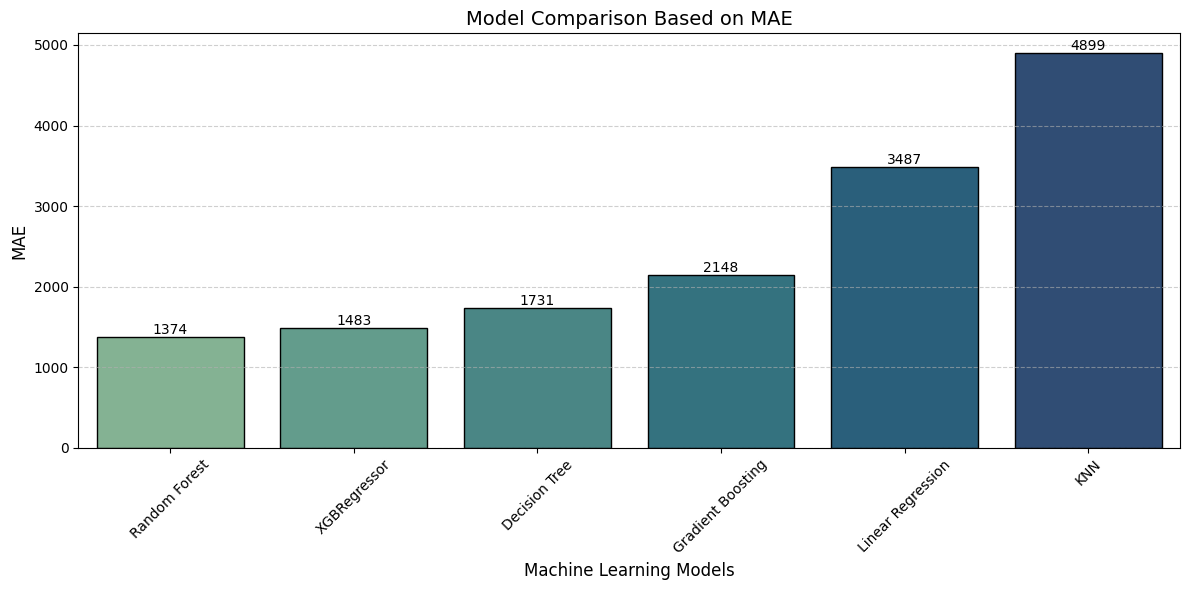

In [120]:
# =====================================
# MODEL COMPARISON USING MAE
# =====================================

# Sort by MAE (lower is better)
results_sorted = results_df.sort_values(by="MAE", ascending=True)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='MAE',
    data=results_sorted,
    palette='crest',
    edgecolor='black'
)

# Add value labels
for i, v in enumerate(results_sorted['MAE']):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom', fontsize=10)

# Titles and labels
plt.title("Model Comparison Based on MAE", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("MAE", fontsize=12)

# Rotate labels
plt.xticks(rotation=45)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

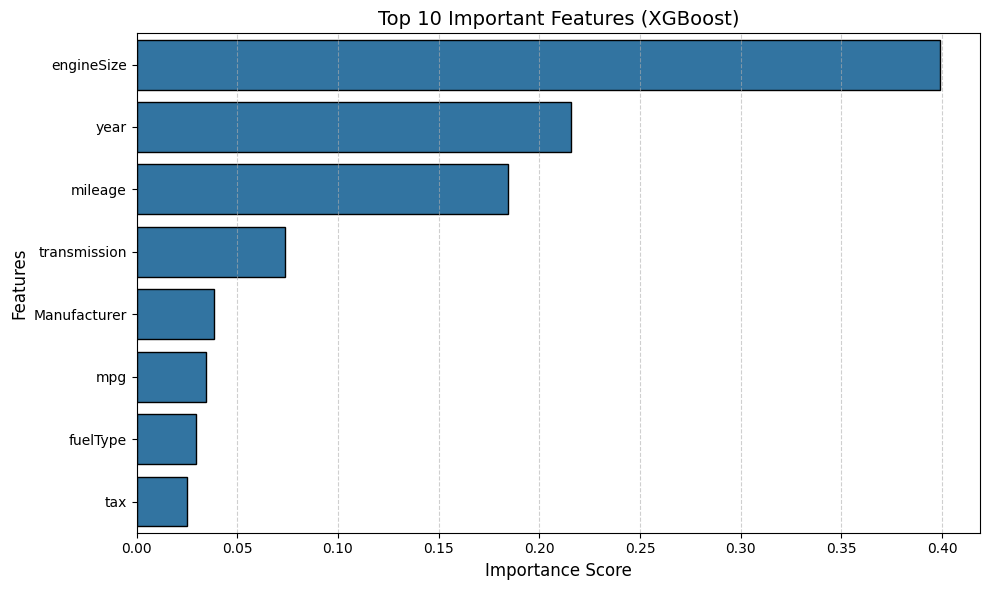

In [121]:
# =====================================
# TOP 10 FEATURE IMPORTANCE (XGBOOST)
# =====================================

# Get feature importance
importances = best_xgb.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Select top 10
top_features = feature_importance_df.head(10)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    edgecolor='black'
)

plt.title("Top 10 Important Features (XGBoost)", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

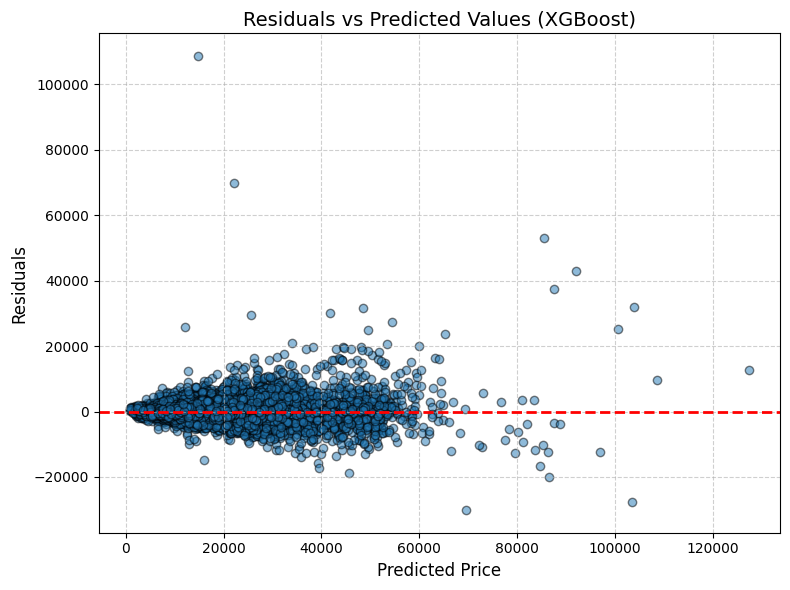

In [122]:
# =====================================
# RESIDUAL SCATTER PLOT
# =====================================

# Calculate residuals
residuals = y_test - y_pred_best

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(y_pred_best, residuals, alpha=0.5, edgecolors='black')

# Horizontal line at 0
plt.axhline(0, color='red', linestyle='--', linewidth=2)

# Labels and title
plt.xlabel("Predicted Price", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.title("Residuals vs Predicted Values (XGBoost)", fontsize=14)

# Grid
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

In [123]:
# =====================================
# SAVE FINAL MODEL
# =====================================

import joblib

# Save trained model
joblib.dump(best_xgb, "car_price_model.pkl")

# Save feature order
joblib.dump(x.columns.tolist(), "features.pkl")

print("Model and features saved successfully!")

Model and features saved successfully!
